## 5장 1강 : 함수의 정의, 실행 과정 및 고급 함수 기법

**function is also an object!**
```javascript
// chrome devTools 
function abc() {

}
```


속성(property)
1. 조회   → obj.key (변수명 규칙 따를 경우) / obj["key"] (변수명 규칙 따르지 않을 경우)
2. 추가   → 없는 속성에 값 대입
3. 수정   → 있는 속성에 값 대입
4. 삭제   → delete obj.key / delete obj["key"]

일급 객체: 함수를 일반 값처럼 자유롭게 사용할 수 있음
- 숫자나 문자열처럼, 함수도 변수에 저장할 수 있다.
- 함수는 배열·객체에 넣을 수 있다.
- 함수를 다른 함수에 전달할 수 있다.
- 함수가 함수를 결과로 돌려줄 수도 있다.
```javascript
// 1. 변수에 담기 
const sayHello = function () {
  console.log("Hello!");
};

// 2. 배열에 넣기
const actions = [
  () => console.log("저장"),
  () => console.log("삭제")
];

// 3. 객체의 값(메서드)으로 넣기
const person = {
  name: "mj",
  introduce: function () {
    console.log(`저는 ${this.name}입니다.`);
  }
};

// 4. 다른 함수의 인자로 전달하기
function run(action) {
  action();
}

run(sayHello); // Hello!
```

---

#### EC와 Call Stack 한눈에 보기
```javascript
function inner() {
  console.log("inner 실행");
}

function outer() {
  inner();
}

outer();
```
① 프로그램 시작

| Call Stack |
| --- |
| **Global EC**<br>전역 변수·함수 |

② 함수 호출

| Call Stack |
| --- |
| **outer EC** |
| **Global EC**<br>전역 변수·함수 |

③ 함수 안의 함수 호출

| Call Stack |
| --- |
| **inner EC**<br>현재 실행 중 |
| **outer EC**<br>실행 대기 |
| **Global EC**<br>실행 대기 |

④ 호출이 끝남

| Call Stack |
| --- |
| **Global EC**<br>다음 코드 실행 |


**실행 컨텍스트(EC)**  
코드 실행에 필요한 변수, 매개변수, `this` 등을 담는 작업 공간

**콜 스택(Call Stack)**  
EC를 호출 순서대로 쌓고, 끝난 함수부터 위에서 제거하는 공간

closure: 함수가 만들어질 당시의 바깥 스코프 변수를 기억해서, 바깥 함수의 실행이 끝난 뒤에도 그 변수에 접근할 수 있는 기능

    - inner가 이미 끝난 outer의 num2: 10을 계속 기억 가능

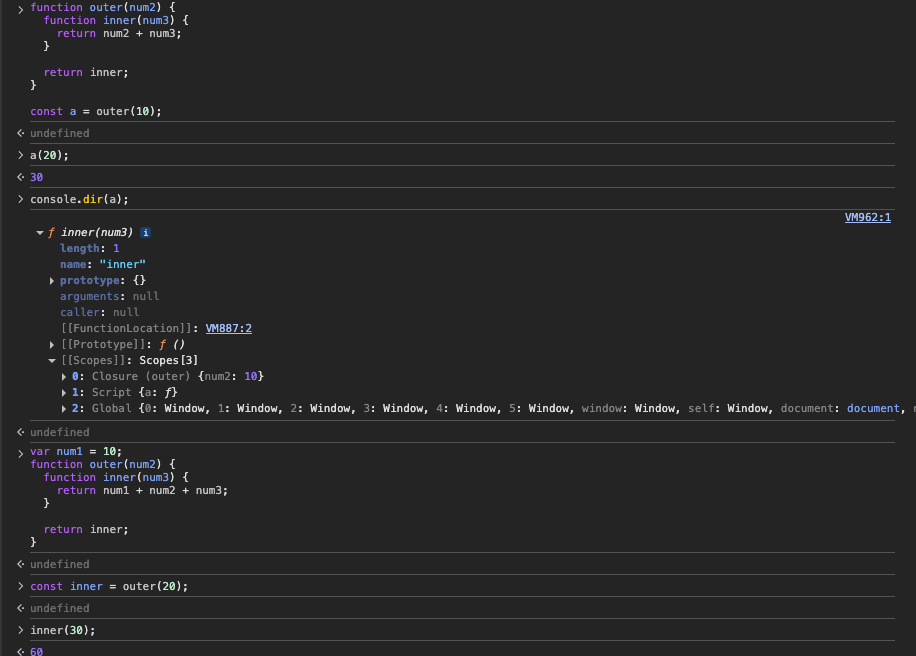

### 1. 함수의 정의와 구성 요소

#### 1.1 함수의 구조
- 함수 이름 (Function Name)
- 매개변수 (Parameter)
- 함수 바디 (Function Body)
- 반환값 (Return Value)
- 인수 (Argument)

### 2. 함수 호출과 제어 흐름

#### 2.1 함수 호출 문법

#### 2.2 함수 호출 시의 제어 흐름

#### 2.3 인수의 유연성과 가변 매개변수

매개변수 기본값 (Default Parameter)

In [ ]:
// num2의 기본값 10 지정. 
// 매개변수 기본값은 끝에서부터 지정 (python과 똑같음)
function add(num1, num2 = 10) { 
    return num1 + num2;
}

add(20);

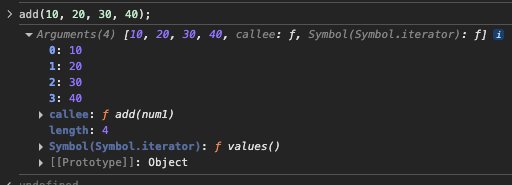

- callee
- Symbol()
- iterator : `for... of...`구문 사용 가능

arguments 객체

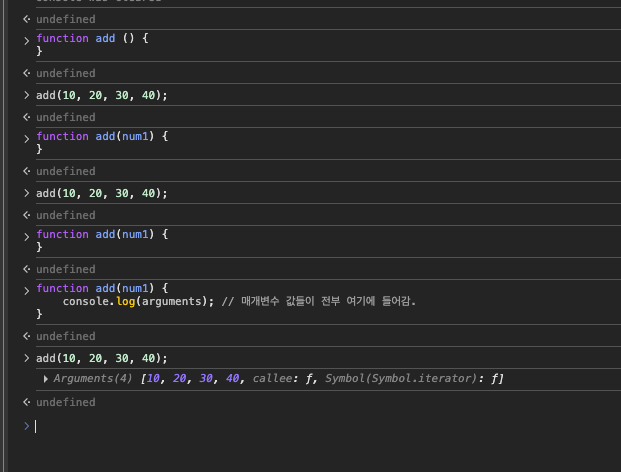

- 함수 안에서 자동으로 만들어지는 실제로 전달된 모든 인자를 담는 객체
- 위 예시에서 JS는 초과된 값을 버리지 않고 `arguments`에 전부 담아둠.
```javascript
function add(num1) {
    // num1 → 첫 번째 값만 받음
    // arguments → 실제로 들어온 값 전체를 봄

    console.log(num1);       // 10
    console.log(arguments);  // [10, 20, 30, 40]
}
```

In [ ]:
// 함수 호출시 사용한 인수 목록
function sum() {
    let total = 0;
    for (const arg of arguments) {
        total += arg;
    }
    return total;
}

In [ ]:
console.log(sum(10, 20));
console.log(sum(10, 20, 30));


나머지 매개변수 (Rest Parameter, 가변 매개변수)

In [ ]:
// ES6+에서 도입
// ... : 가변 매개변수
function sum(...params) {
    console.log(params);
}

sum(10, 20, 30, 40);

In [ ]:
function sum(num1, ...params) {
    console.log(num1);

    for (const p of params) {
        console.log(p);
    }
}

sum(10, 20, 30, 40);

In [ ]:
// 전개 연산자
function add(num1, num2) {
    return num1 + num2;
}

const nums = [10, 20];

console.log(add(nums[0], nums[1]));
console.log(add(...nums));

In [ ]:
const nums1 = [10, 20, 30, 40];
let nums2 = nums1; // 얕은 복사
console.log(nums1 === nums2);
nums2 = [...nums1];
console.log(nums2, ",", nums1 === nums2); // 전개해서 새로운 값 복사시 깊은복사

In [ ]:
const person = {
    name: "김철수",
    age: 20
};
const person2 = {...person}; // key-value도 전개 가능
console.log(person2, ",", person === person2);

In [ ]:
const person3 = {...person, address: "주소", natioanlity: "대한민국"}; ///전개해서 key-value값을 추가하는 방법
console.log(person3);

#### 비구조화 할당
- 구조 -> 비구조화 (구조 분해) -> 변수에 할당

In [ ]:
const nums = [10, 20, 30, 40, 50];
const [a, b, c] = nums;
console.log(a, b, c);

In [ ]:
const [a, ,c] = nums;
console.log(a, c);

In [ ]:
const [a, ,c] = [10, 20, 30, 40, 50]; // 바로 할당도 가능 (python에서는 _ 활용)
console.log(a, c);

In [ ]:
const [a, b, ...rest] = nums;
console.log(a, b, rest);

In [ ]:
const person = {name: "김철수", age: 20};
const name = person.name;
const age = person.age;

console.log(name, age);

In [ ]:
const {name: a, age: b} = person; //person 객체에서 key에 해당하는 value를 찾아 a, b 변수에 할당
console.log(a); // typescript 엔진으로 인해 문법적 오류 엄격하게 검사되어 vscode에서 실행되지 않음 -> devtools console에서 확인

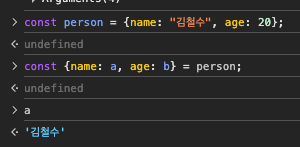

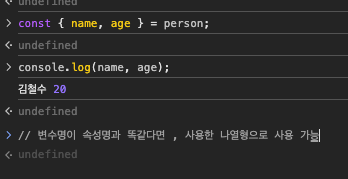

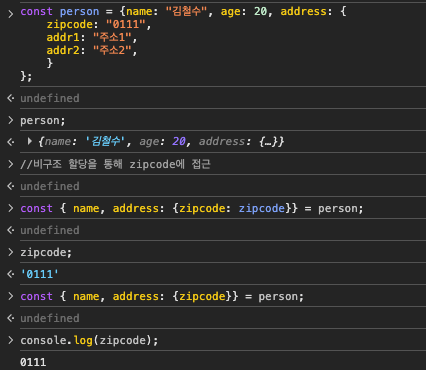

### 3. 함수 정의 방식: 선언문 vs 표현식

#### 3.1 함수 선언문 방식
- 호이스팅 여부

In [ ]:
// 호이스팅 됨
abc();
function abc(num1, num2) {

}

#### 3.2 함수 리터럴(표현식) 방식
- 호이스팅 여부

In [ ]:
abc();
const abc = function(num1, num2) {

};

// 1:1 - Block-scoped variable 'abc' used before its declaration.

#### 4. 값으로서의 함수 (일급 객체)와 콜백

#### 4.1 용어의 유래: 차별 없는 '동등한 권리’

#### 4.2 일급 객체로서의 3대 속성
- 변수 할당 (Assignment)
- 매개변수 전달 (Argument Passing) / callback / 사용자정의 함수 / 
- 반환값 활용 (Return Value)

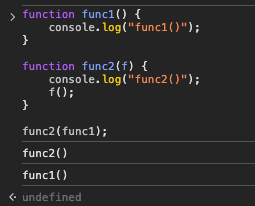

In [ ]:
function func1() {
    console.log("func1()");
}

function func2(f) {
    console.log("func2()");
    f();
}

func2(func1());

In [ ]:
function square(num) { // 한번 쓰고 버려지는 함수 -> 함수 정의 따로하는 건 비추천. 메모리 차지.
    return num * num;
}

function calc(nums, callback) { // 사용자정의 함수(callback function). calc()에서는 callback의 기능을 모르지만 '함수'라는 역할만 알고 있는 상황.
    let total = 0;
    for (const num of nums) {
        if (typeof callback === 'function') {
            total += callback(num);
        }
    }
    return total;
}


In [95]:
calc([10, 20, 30], square);

1400


In [99]:
calc([10, 20, 30], function(num) { // function(num) -> annonymous function
    return num * num;
});

1400


### 5. 화살표 함수 (Arrow Function)

- 매개변수나 callback일때 주로 사용

In [101]:
calc([10, 20, 30], num => num * num);

1400


#### 5.1 정의 방법 및 스코프 생략 규칙

- `function` keyword 생략
- 매개변수 정의부와 코드 실행 영역 {} 사이를 `=>`로 표기
- 코드 구현 부분이 한줄이면 {} 생략 가능. `return`도 생략해야 함
- 매개변수명도 한글자면 충분 (한번 쓰고 버릴거라 상관없음)
- 매개변수 하나면 소괄호 생략 가능

In [102]:
function square(num) {
    return num * num;
}

In [104]:
const square2 = (num) => {
    return num * num;
};
square2(10);

100


In [108]:
const square3 = x => x * x;
square3(10);

100


#### 5.2 화살표 함수의 제한 사항
- 생성자 함수 사용 불가
- arguments 객체 미지원
- yield 사용 불가
- `console.dir()`로 확인 시 `prototype`이 없음 -> 상속 불가(객체생성불가)

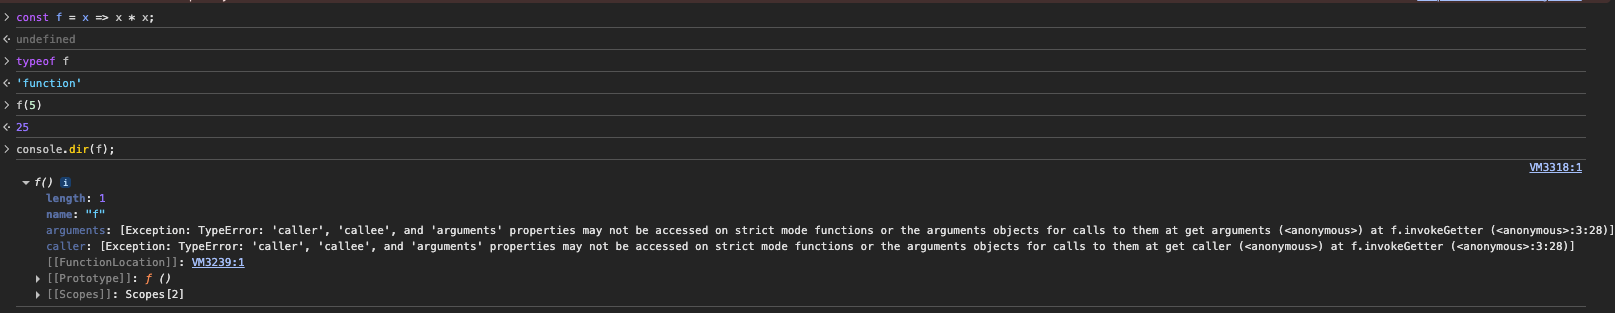

- `[[prototype]]`: f 자체가 상속받는 부모, 내부 슬롯. `Object.getPrototypeOf(f)`로 확인 가능
- `.prototype`: 생성자 함수가 자식에게 물려줄 객체

#### 5.3 일반 함수 vs 화살표 함수의 this 바인딩 비교

- 일반 함수의 this: 함수가 호출되면 호출한 객체
- 화살표 함수의 this: 함수가 정의되는 시점에 이미 결정되어 있는 this로 정의됨

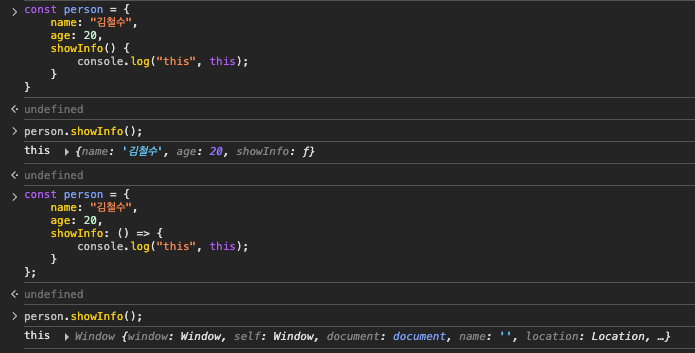

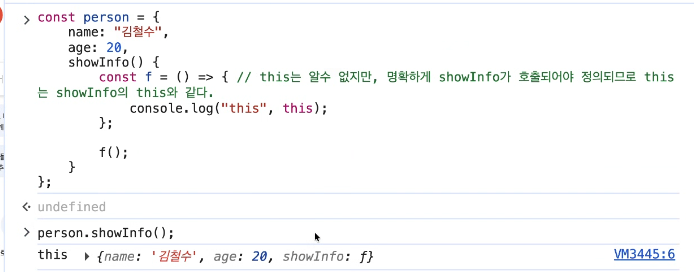

- `person.showInfo()`가 호출되지 않으면 this는 호출되지 않음

- 실행 스코프 this가 호출 (global EC window)

#### 6. 자바스크립트 실행 평가 과정과 클로저 (Closure)

#### 6.1 엔진의 2단계 제어 프로세스

- 1단계: 평가 단계 (Creation/Evaluation Phase)
- 2단계: 실행 단계 (Execution Phase)

#### 6.2 데이터 정렬과 호출 스택 (Call Stack)의 동작 방식

#### 6.3 클로저 (Closure)의 생성과 작동 원리

유효범위체인(scopes)


- 내부함수 inner()가 외부함수의 지역변수 num2와 글로벌 num1을 참조

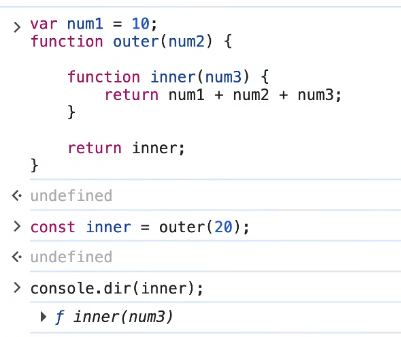

Higher Order Function
- closure의 특징을 이용

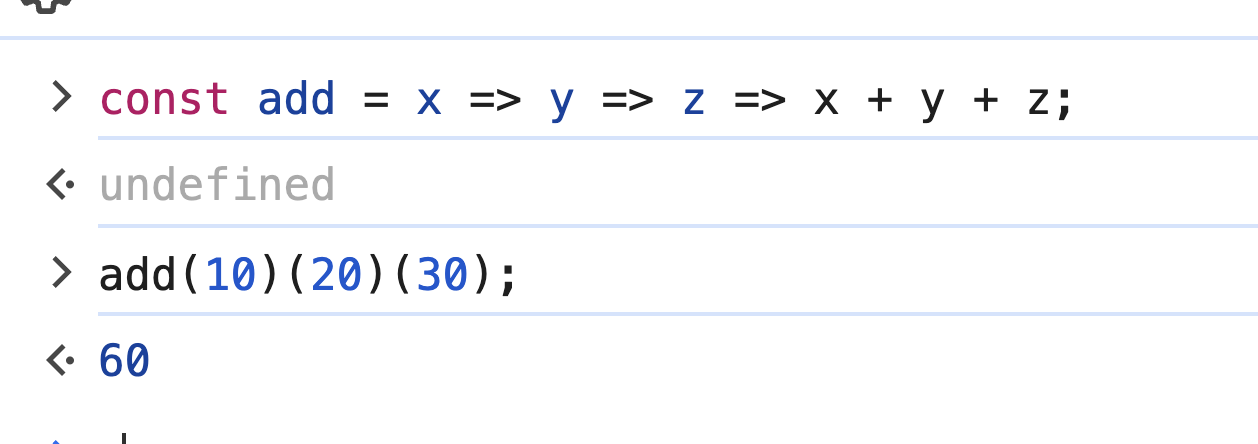

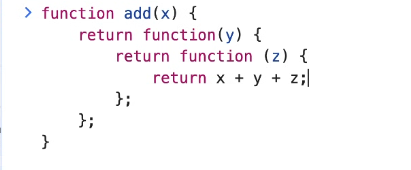

- 팩토리 함수

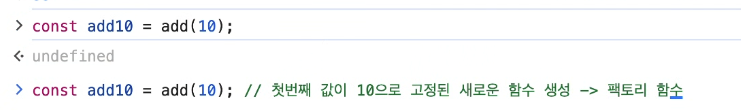

- 비동기 처리시 사용하는 고차함수

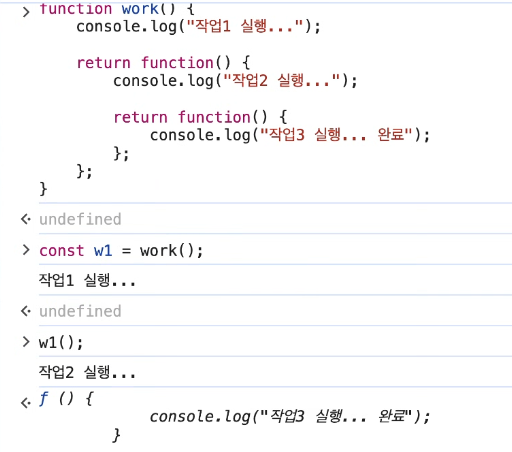

#### 7. 명시적 this 바인딩 (call, apply, bind)

함수 내부의 this 주체를 런타임에 인위적으로 결정하고 싶을 때 사용

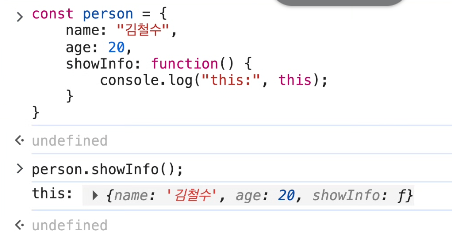

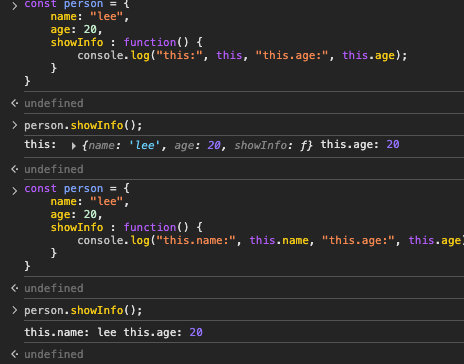

모든 함수 객체는 prototype을 상속받는다? 그럼 arrow function은??

접근자 프로퍼티

#### 7.1 call 메서드

call 메서드는 함수를 즉시 실행하면서, 첫 번째 인수로 전달받은 객체를 해당 함수의 this로 강제 지정

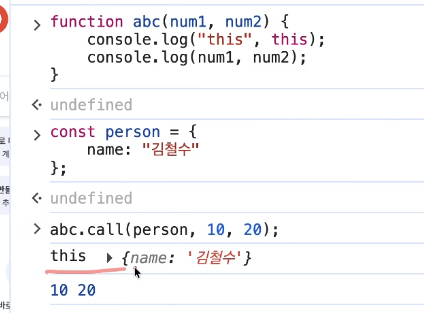

#### 7.2 apply 메서드

- apply 메서드는 call과 동일하게 함수를 즉시 실행하며 this를 고정
- 차이점은 함수에 넘겨줄 인수들을 개별적으로 쓰는 것이 아니라 하나의 배열 형태로 한꺼번에 전달한다는 점

#### 7.3 bind 메서드

- 호출시 새로운 함수 생성
- `func.bind(thisArg[, arg1[, arg2[, ...]]])`

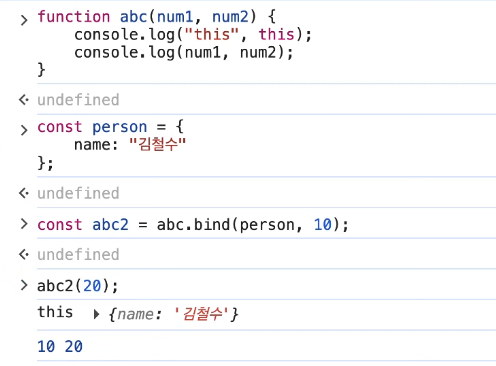

### generator
- `function*`
- `yield`
- `next()`

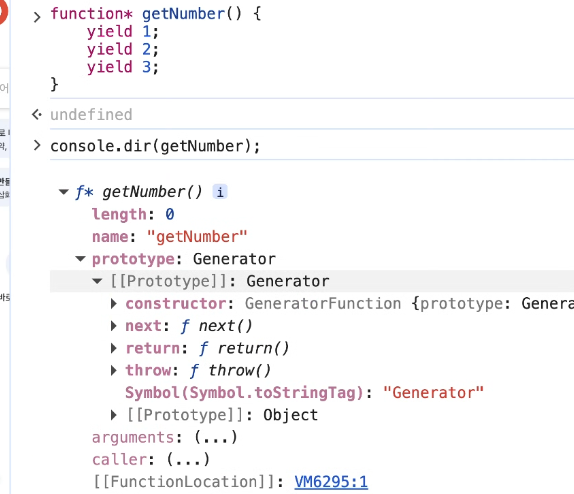

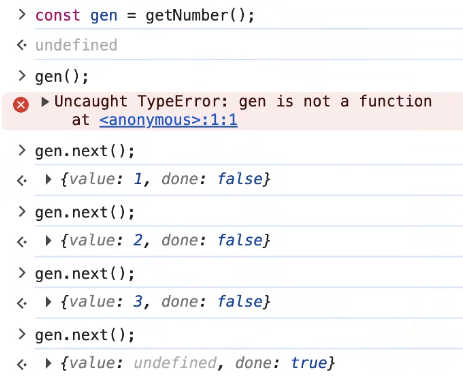